 # AgroPortal using ATSC

In [1]:
library("evaluomeR")
library("dplyr")
library("ggplot2")
library("ggrepel")
library("reshape2")

options(scipen=10)
options(repr.plot.width=12, repr.plot.height=12)

Cargando paquete requerido: SummarizedExperiment

Cargando paquete requerido: MatrixGenerics

Cargando paquete requerido: matrixStats


Adjuntando el paquete: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles,

# Install evaluomeR 1.8.1

In [2]:
#install.packages("devtools")
#library(devtools)
#devtools::install_github("neobernad/evaluomeR@v1.8.1")

In [3]:
# Check R version > 4.4 and evaluomeR is 1.8.1
getRversion()
packageVersion("evaluomeR")

[1] '4.4.1'

[1] '1.8.1'

# Dataset <a class="anchor" id="dataset"></a>

In [4]:
seed = 13606
k.range = c(3,10)
cbi = "kmeans" # Run evaluomeR::evaluomeRSupportedCBI() to get available clustering techniques
alpha = NULL # If NULL, then get best alpha until max_alpha is run
max_alpha = 0.2 # Default 0.1

In [5]:
agro <- read.csv("../examples/data/agro.csv", stringsAsFactors = FALSE)
dataset = agro
head(dataset)
unique(dataset$Description)

,Description,ANOnto,AROnto,CBOOnto,CBOOnto2,CROnto,DITOnto,INROnto,LCOMOnto,NACOnto,NOCOnto,NOMOnto,POnto,PROnto,RFCOnto,RROnto,TMOnto,TMOnto2,WMCOnto,WMCOnto2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ADO,0.0000000,3.9503849,0.9991446,0.9991446,0.9957228,3,0.9991446,1.999142,1.000000,292.000000,2.9632164,0.9957228,0.7478411,3.9623610,0.252158895,0.00000000,0.000000,1.999142,1.000000
2,AEO,0.9298246,0.5438596,0.9824561,0.9824561,0.0000000,5,0.9824561,2.357143,1.000000,3.733333,0.9824561,0.5789474,0.5000000,1.9649123,0.500000000,0.00000000,0.000000,2.357143,1.000000
3,AFO,0.7500000,0.0000000,0.8750000,0.8750000,3998.8750000,3,0.8750000,1.333333,1.000000,3.500000,2275.7500000,0.2500000,0.9996157,2276.6250000,0.000384341,0.00000000,0.000000,1.333333,1.000000
4,AGRO,0.9907407,3.1018519,1.0694444,1.0694444,0.3634259,16,1.0694444,7.695971,1.052174,2.287129,1.2037037,1.0555556,0.5295316,2.2731481,0.470468432,0.06264501,2.148148,9.134783,1.186957
5,AGRORDF,1.2362637,0.0000000,1.0659341,1.0659341,0.0000000,6,1.0329670,2.467532,1.077465,4.700000,0.5879121,0.8571429,0.3627119,1.6538462,0.637288136,0.07182320,2.000000,2.676056,1.084507
6,ANAEETHES,0.0000000,0.0000000,0.6666667,0.6666667,1107.6666670,2,0.6666667,1.000000,1.000000,2.000000,0.0000000,0.0000000,0.0000000,0.6666667,1.000000000,0.00000000,0.000000,1.000000,1.000000


[1] "ADO"            "AEO"            "AFO"            "AGRO"          
 [5] "AGRORDF"        "ANAEETHES"      "ASCOPAIN-T"     "ATOL"          
 [9] "BCO"            "BFO"            "BIOREFINERY"    "CDAO"          
[13] "CL"             "CO_020"         "CO_121"         "CO_125"        
[17] "CO_320"         "CO_321"         "CO_322"         "CO_324"        
[21] "CO_325"         "CO_327"         "CO_330"         "CO_331"        
[25] "CO_333"         "CO_334"         "CO_335"         "CO_339"        
[29] "CO_340"         "CO_341"         "CO_343"         "CO_345"        
[33] "CO_346"         "CO_347"         "CO_348"         "CO_350"        
[37] "CO_357"         "CO_715"         "CROPUSAGE"      "DSW"           
[41] "DURUM_WHEAT"    "EDAM"           "EFO"            "ENVO"          
[45] "EO"             "EOL"            "FALDO"          "FLOPO"         
[49] "FOODIE"         "FOODON"         "GACS"           "GECO"          
[53] "GFVO"           "GO"             "GR-TAX"         "MS2O"          
[57] "NALT"           "NCBITAXON"      "OBOE"           "OFPE"          
[61] "ONTOBIOTOPE"    "PATO"           "PCO"            "PO"            
[65] "PO2"            "PPEO"           "RO"             "SIO"           
[69] "SO"             "SOY"            "STY"            "TO"            
[73] "TOP"            "TRANSMAT"       "TRIPHASE"       "VARIO"         
[77] "VT"             "WHEATPHENOTYPE"

In [6]:
dataset_clean = evaluomeR::cleanDataset(dataset, correlation_threshold=1)
pca_suitability = evaluomeR::PCASuitability(dataset_clean$R, sig_level = 0.05)
dataset = dataset_clean$dataset

if (pca_suitability$pca_suitable) {
    r_pca = evaluomeR::performPCA(dataset = dataset)
    dataset = r_pca$dataset_ncp
    evaluomeR::plotPCA_fviz_screeplot(r_pca$pca)
    evaluomeR::plotPCA_fviz_biplot(r_pca$pca)
}
head(dataset)

Preprocessing dataset

Removing non-numeric columns...

	Columns are numeric

Removing correlations...

	Removing correlated column: CBOOnto

	Removing correlated column: PROnto

Checking PCA suitability...

Warning message in log(detR):
"Se han producido NaNs"
	PCA is not suitable. Bartlett's test produced NA for p-value.



,Description,ANOnto,AROnto,CBOOnto2,CROnto,DITOnto,INROnto,LCOMOnto,NACOnto,NOCOnto,NOMOnto,POnto,RFCOnto,RROnto,TMOnto,TMOnto2,WMCOnto,WMCOnto2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ADO,0.0000000,3.9503849,0.9991446,0.9957228,3,0.9991446,1.999142,1.000000,292.000000,2.9632164,0.9957228,3.9623610,0.252158895,0.00000000,0.000000,1.999142,1.000000
2,AEO,0.9298246,0.5438596,0.9824561,0.0000000,5,0.9824561,2.357143,1.000000,3.733333,0.9824561,0.5789474,1.9649123,0.500000000,0.00000000,0.000000,2.357143,1.000000
3,AFO,0.7500000,0.0000000,0.8750000,3998.8750000,3,0.8750000,1.333333,1.000000,3.500000,2275.7500000,0.2500000,2276.6250000,0.000384341,0.00000000,0.000000,1.333333,1.000000
4,AGRO,0.9907407,3.1018519,1.0694444,0.3634259,16,1.0694444,7.695971,1.052174,2.287129,1.2037037,1.0555556,2.2731481,0.470468432,0.06264501,2.148148,9.134783,1.186957
5,AGRORDF,1.2362637,0.0000000,1.0659341,0.0000000,6,1.0329670,2.467532,1.077465,4.700000,0.5879121,0.8571429,1.6538462,0.637288136,0.07182320,2.000000,2.676056,1.084507
6,ANAEETHES,0.0000000,0.0000000,0.6666667,1107.6666670,2,0.6666667,1.000000,1.000000,2.000000,0.0000000,0.0000000,0.6666667,1.000000000,0.00000000,0.000000,1.000000,1.000000


# evaluomeR - (ATSC) optimal $k$ analysis <a class="anchor" id="evaluomeR"></a>

In [7]:
r_atsc = evaluomeR::ATSC(data=dataset, k.range=k.range, cbi=cbi, alpha=alpha, 
                         max_alpha=max_alpha, gold_standard=NULL, seed=seed)

Computing optimal k value with 'kmeans'



Data loaded.
Number of rows: 78
Number of columns: 18



Processing all metrics, 'merge', in dataframe (17)

	Calculation of k = 3

	Calculation of k = 4

	Calculation of k = 5

	Calculation of k = 6

	Calculation of k = 7

	Calculation of k = 8

	Calculation of k = 9

	Calculation of k = 10



Data loaded.
Number of rows: 78
Number of columns: 18



Processing all metrics, 'merge', in dataframe (17)

	Calculation of k = 3

	Calculation of k = 4

	Calculation of k = 5

	Calculation of k = 6

	Calculation of k = 7

	Calculation of k = 8

	Calculation of k = 9

	Calculation of k = 10

Processing metric: all_metrics


	Both Ks do not have a stable classification: '10', '3'


	Using '3' since it provides higher silhouette width


Optimal k: 3

Determining best L1 and alpha parameter automatically, it might take a while...

Computing best L1 boundry with 'sparcl::KMeansSparseCluster.permute'

Best L1 found is: 2

Running stability and quality index

In [8]:
print(paste0("ATSC Optimal k: ", r_atsc$optimalK_ATSC))
print(paste0("Best L1 boundry found: ", r_atsc$L1))
print(paste0("Best alpha found: ", r_atsc$alpha))
if (!is.null(r_atsc$gold_standard_trimmed)) {
    print(paste0("Gold standard vector trimmed, current values are:"))
    print(gold_standard_vector)
    print("After:")
    print(r_atsc$gold_standard_trimmed)
    gold_standard_vector = r_atsc$gold_standard_trimmed
}

[1] "ATSC Optimal k: 3"
[1] "Best L1 boundry found: 2"
[1] "Best alpha found: 0"


## Stability <a class="anchor" id="evaluomeR_stab_plot"></a>

Stability without ATSC and with ATSC

In [9]:
stab = r_atsc$stab
rownames(stab) = c(paste0("stab_", cbi))
stab$Metric = rownames(stab)
stab$Method = "without ATSC"
stab_melt = melt(stab, id.vars = c("Metric", "Method"))

stab_ATSC = r_atsc$stab_ATSC
rownames(stab_ATSC) = c(paste0("stab_", "ATSC"))
stab_ATSC$Metric = rownames(stab_ATSC)
stab_ATSC$Method = "with ATSC"
stab_ATSC_melt = melt(stab_ATSC, id.vars = c("Metric", "Method"))

In [10]:
stab

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_kmeans,0.6858984,0.6734864,0.659674,0.665093,0.6673243,0.676652,0.6665802,0.6966746,stab_kmeans,without ATSC


In [11]:
stab_ATSC

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_ATSC,0.6858984,0.6734864,0.659674,0.665093,0.6673243,0.676652,0.6665802,0.6966746,stab_ATSC,with ATSC


## Quality <a class="anchor" id="evaluomeR_qual_plot"></a>

Quality without ATSC and with ATSC

In [12]:
qual = r_atsc$qual
rownames(qual) = c(paste0("qual_", cbi))
qual$Metric = rownames(qual)
qual$Method = "without ATSC"
qual_melt = melt(qual, id.vars = c("Metric", "Method"))

qual_ATSC = r_atsc$qual_ATSC
rownames(qual_ATSC) = c(paste0("qual_", "ATSC"))
qual_ATSC$Metric = rownames(qual_ATSC)
qual_ATSC$Method = "with ATSC"
qual_ATSC_melt = melt(qual_ATSC, id.vars = c("Metric", "Method"))

In [13]:
qual

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_kmeans,0.965218,0.9491783,0.9192771,0.864715,0.838444,0.5980611,0.3331821,0.3518982,qual_kmeans,without ATSC


In [14]:
qual_ATSC

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_ATSC,0.965218,0.9491783,0.9192771,0.864715,0.838444,0.5980611,0.3331821,0.3518982,qual_ATSC,with ATSC


Determining the optimal $k$ given the stabilities and qualities in `stab_range` and `qual_range` objects:

In [15]:
print(paste0("Stabilities and qualities per k with '", cbi, "' as clustering method"))
stab
qual
print(paste0("Stabily in k=", r_atsc$optimalK,": ", stab[paste0("k_",r_atsc$optimalK)]))
print(paste0("Quality in k=", r_atsc$optimalK,": ", qual[paste0("k_",r_atsc$optimalK)]))

[1] "Stabilities and qualities per k with 'kmeans' as clustering method"


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_kmeans,0.6858984,0.6734864,0.659674,0.665093,0.6673243,0.676652,0.6665802,0.6966746,stab_kmeans,without ATSC


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_kmeans,0.965218,0.9491783,0.9192771,0.864715,0.838444,0.5980611,0.3331821,0.3518982,qual_kmeans,without ATSC


[1] "Stabily in k=3: 0.685898409500602"
[1] "Quality in k=3: 0.965218021881175"


In [16]:
print(paste0("Stabilities and qualities per k with 'ATSC' as clustering method"))
stab_ATSC
qual_ATSC
print(paste0("Stabily in k=", r_atsc$optimalK_ATSC,": ", stab_ATSC[paste0("k_",r_atsc$optimalK_ATSC)]))
print(paste0("Quality in k=", r_atsc$optimalK_ATSC,": ", qual_ATSC[paste0("k_",r_atsc$optimalK_ATSC)]))

[1] "Stabilities and qualities per k with 'ATSC' as clustering method"


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_ATSC,0.6858984,0.6734864,0.659674,0.665093,0.6673243,0.676652,0.6665802,0.6966746,stab_ATSC,with ATSC


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_ATSC,0.965218,0.9491783,0.9192771,0.864715,0.838444,0.5980611,0.3331821,0.3518982,qual_ATSC,with ATSC


[1] "Stabily in k=3: 0.685898409500602"
[1] "Quality in k=3: 0.965218021881175"


# Clusters

In [17]:
# Internal method used to group individuals per cluster
individuals_per_cluster = function(qualityResult) {
    
  qual_df = as.data.frame(assay(qualityResult))
    

  cluster_pos_str = as.character(unlist(qual_df["Cluster_position"]))
  cluster_labels_str = as.character(unlist(qual_df["Cluster_labels"]))

  cluster_pos = as.list(strsplit(cluster_pos_str, ",")[[1]])
  cluster_labels = as.list(strsplit(cluster_labels_str, ",")[[1]])

  individuals_in_cluster = as.data.frame(cbind(cluster_labels, cluster_pos))
  colnames(individuals_in_cluster) = c("Individual", "Cluster")

  return(individuals_in_cluster)
}

In [18]:
dataset = r_atsc$trimmmedDataset
qual_range = qualityRange(data=dataset, k.range=k.range, 
                            all_metrics=TRUE, seed=seed,
                            cbi=cbi)
optimal_k = r_atsc$optimalK_ATSC
cluster_individuals = individuals_per_cluster(assay(qual_range[paste0("k_",optimal_k)]))
print(paste0("CBI: ", cbi, " - k: ", optimal_k))
for (cluster_i in 1:optimal_k) {
    ind_in_cluster = paste(unlist(cluster_individuals[cluster_individuals$Cluster == cluster_i, ]["Individual"]), collapse = ",")
    print(paste("Cluster", cluster_i, ":", ind_in_cluster))
    print("")
}



Data loaded.
Number of rows: 78
Number of columns: 18



Processing all metrics, 'merge', in dataframe (17)

	Calculation of k = 3

	Calculation of k = 4

	Calculation of k = 5

	Calculation of k = 6

	Calculation of k = 7

	Calculation of k = 8

	Calculation of k = 9

	Calculation of k = 10



[1] "CBI: kmeans - k: 3"
[1] "Cluster 1 : GACS"
[1] ""
[1] "Cluster 2 : ADO,AEO,AFO,AGRO,AGRORDF,ANAEETHES,ASCOPAIN-T,ATOL,BCO,BFO,BIOREFINERY,CDAO,CL,CO_020,CO_121,CO_125,CO_320,CO_321,CO_322,CO_324,CO_325,CO_327,CO_330,CO_331,CO_333,CO_334,CO_335,CO_339,CO_340,CO_341,CO_343,CO_345,CO_346,CO_347,CO_348,CO_350,CO_357,CO_715,CROPUSAGE,DSW,DURUM_WHEAT,EDAM,EFO,ENVO,EO,EOL,FALDO,FLOPO,FOODIE,FOODON,GECO,GFVO,GO,GR-TAX,MS2O,NCBITAXON,OBOE,OFPE,ONTOBIOTOPE,PATO,PCO,PO,PO2,PPEO,RO,SIO,SO,SOY,STY,TO,TOP,TRANSMAT,TRIPHASE,VARIO,VT,WHEATPHENOTYPE"
[1] ""
[1] "Cluster 3 : NALT"
[1] ""


# PCA <a class="anchor" id="pca"></a>
We employ Principal Component Analysis (PCA) as a dimensionality reduction technique to facilitate the visualization of clusters within our dataset. PCA allow us to transform the original high-dimensional data into a lower-dimensional space, while preserving as much of the variability as possible.

In [19]:
dataset["Cluster"] = as.factor(as.numeric(cluster_individuals$Cluster))
if (pca_suitability$pca_suitable) {
    pca_df = dataset
} else {
    pca_matrix = dataset %>% select(-Cluster)
    r_pca = evaluomeR::performPCA(dataset = pca_matrix)
    pca_df = r_pca$dataset_ncp
    pca_df$Cluster <- as.factor(dataset$Cluster)
    pca_df$Description <- dataset$Description
}
head(pca_df)

Parameter 'npc' is null. Computing number of factors automatically:

Number of factors, 'ncp' used is: 6



,Description,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Cluster
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,ADO,-1.6622579,-0.2349007,-1.9219012,1.4733478,-5.047385620,4.19784592,2
2,AEO,-1.4052442,-0.2314763,-0.5313703,0.4093505,0.015059752,-0.74150709,2
3,AFO,-3.7752109,7.5584855,0.8859379,0.7829065,0.842511032,0.40058246,2
4,AGRO,1.2657137,-0.2747358,1.4103215,0.5235838,0.004904616,0.08247899,2
5,AGRORDF,0.2521693,-0.3316388,-0.1796231,0.6805521,0.818521502,-0.46475227,2
6,ANAEETHES,-3.4910729,-0.4207317,-0.8033980,-2.8780889,-0.571752312,-1.23144585,2


In [20]:
# Creating shapes for individuals
pca_df <- pca_df %>%
  mutate(
    # Extract the letter from the Description column
    Letter = Description,
  )

In [21]:
tail(pca_df)

,Description,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Cluster,Letter
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
73,TOP,-0.2406009,-0.8291183,0.3005119,-0.5627768,0.9452094,0.09829331,2,TOP
74,TRANSMAT,0.1978219,-0.5393414,0.4075283,-1.2539640,-0.2642698,0.68844544,2,TRANSMAT
75,TRIPHASE,0.7114968,-0.9304352,1.1287942,-0.7018844,1.0901343,0.75704898,2,TRIPHASE
76,VARIO,0.2046519,-0.8370229,0.6042736,-0.3225572,1.0166736,0.41522130,2,VARIO
77,VT,2.8349892,-0.3609765,0.3246498,-0.3916255,1.1726501,0.63979972,2,VT
78,WHEATPHENOTYPE,0.3936225,-0.7963187,0.8075779,-0.3132284,0.9574482,0.50831308,2,WHEATPHENOTYPE


Too few points to calculate an ellipse
Too few points to calculate an ellipse
Warning message:
"The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"
Warning message:
"ggrepel: 67 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


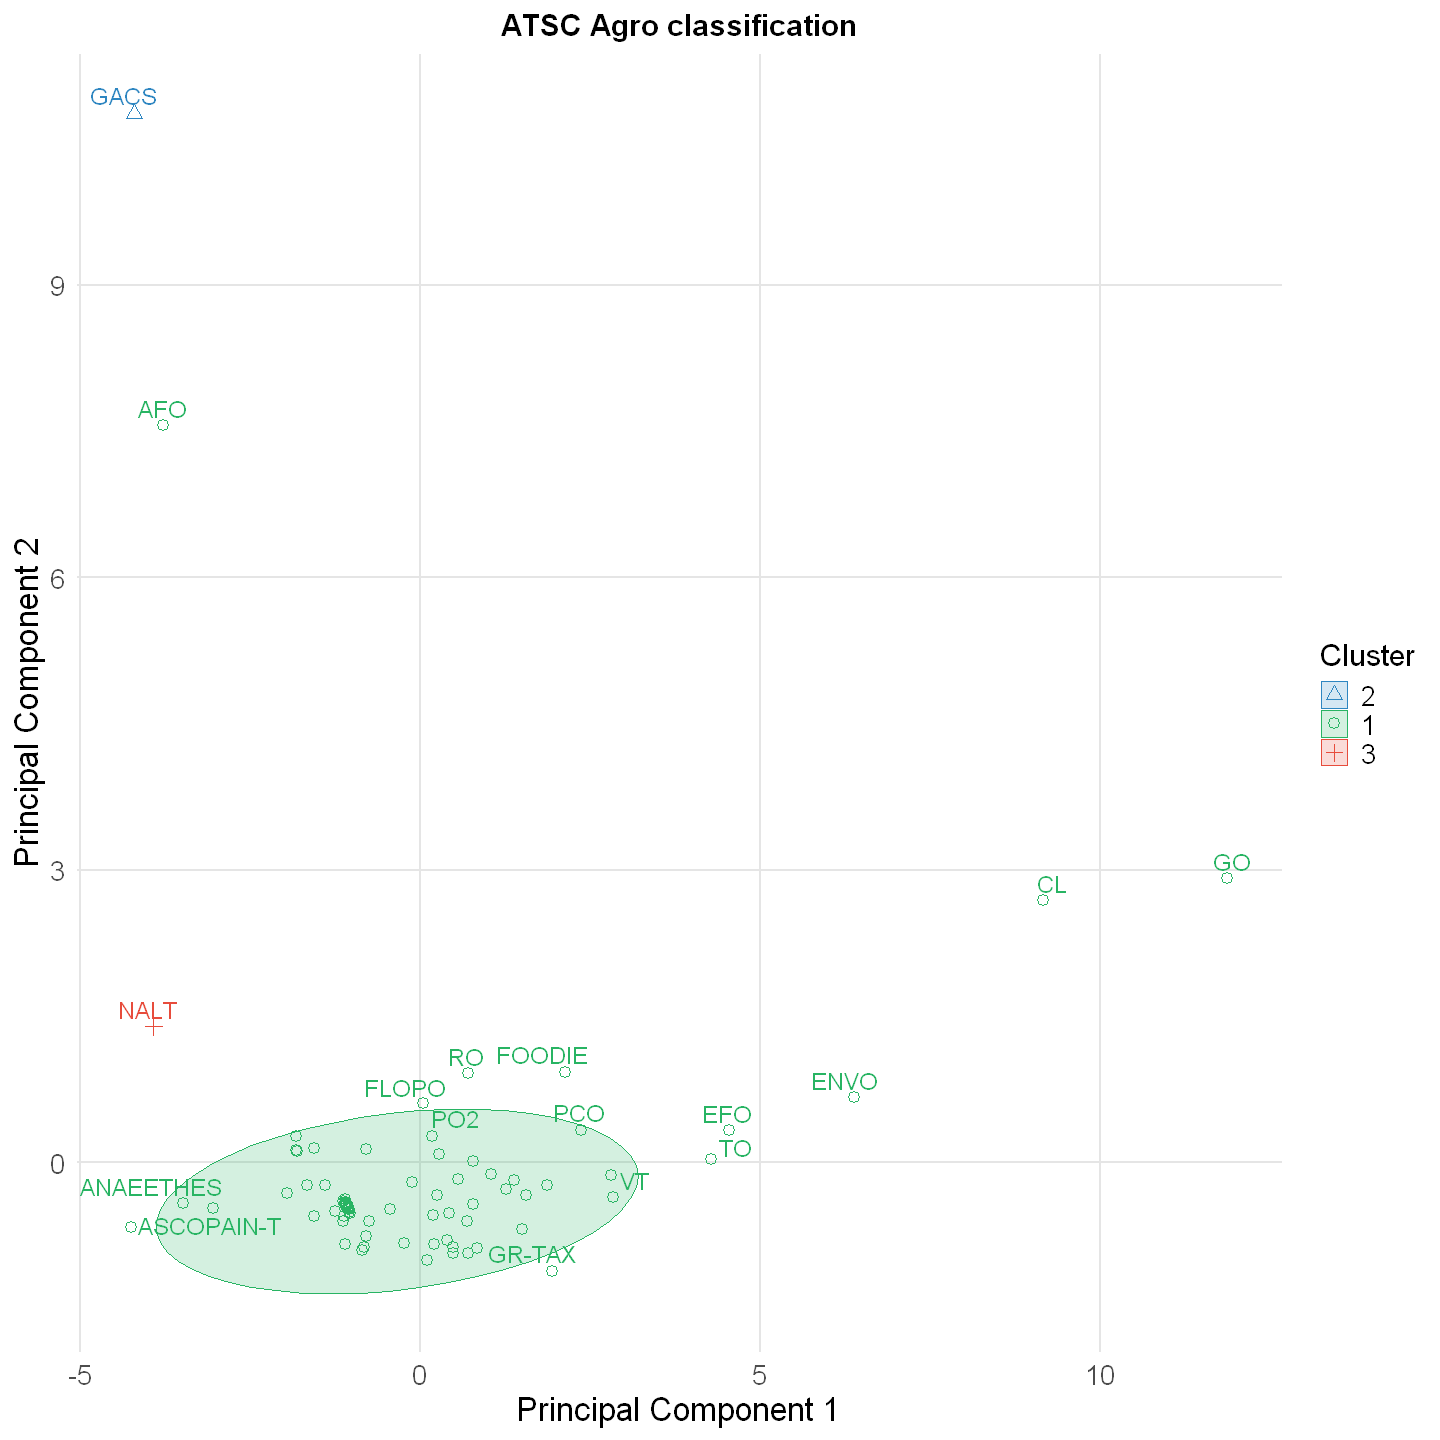

In [22]:
cluster_colors <- c("#2E86C1", "#28B463", "#E74C3C", "#9B59B6", "#F1C40F", "#7F8C8D", 
            "#D35400", "#8E44AD", "#16A085")

cluster_shapes = unique(pca_df$Cluster)
cluster_labels = unique(pca_df$Cluster)

ggplot(pca_df, aes(x = Dim.1, y = Dim.2, shape = Cluster, color = Cluster, label = Description)) +
  geom_point(size = 3) +
  geom_text_repel(
    vjust = 1,
    hjust = 1,
    size = 5,
    show.legend = FALSE,
    point.padding = 0.4,
    box.padding = 0.25,
    max.overlaps = 5,
    segment.color = "grey70",
    segment.size = 0.2
  ) +
  stat_ellipse(aes(fill = Cluster, group = Cluster), level = 0.95, alpha = 0.2, geom = "polygon") +
  labs(
    title = "ATSC Agro classification",
    x = "Principal Component 1",
    y = "Principal Component 2"
  ) +
  scale_shape_manual(values = cluster_shapes, labels = unique(pca_df$Cluster)) +
  scale_color_manual(values = cluster_colors, labels = cluster_labels)  +
  scale_fill_manual(values = cluster_colors, labels = cluster_labels)   +
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"),
    axis.title.x = element_text(size = 20),
    axis.title.y = element_text(size = 20),
    axis.text = element_text(size = 16),
    legend.position = "right",
    legend.title = element_text(size = 18),
    legend.text = element_text(size = 16),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_blank()
  )